In [1]:
# GPT-Neo + LoRA on ROCStories — Clean, runnable notebook/script
# -----------------------------------------------------------------
# This single-file Python script is a cleaned, corrected, and self-contained
# version of the notebook you supplied. It is written so it can be executed
# in a Colab / notebook environment cell-by-cell or as a script with
# minor modifications (esp. paths and CUDA availability).

# === Cell 0: Install dependencies===
!pip install -q transformers datasets accelerate peft evaluate sentence-transformers nltk sacrebleu rouge-score bert-score


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.0 MB/s eta 0:00:00


In [2]:
# === Cell 1: Imports & Global Config ===
import os
import re
import math
import random
from typing import List

import numpy as np
import torch
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from nltk import sent_tokenize
from sentence_transformers import SentenceTransformer

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)

from peft import LoraConfig, get_peft_model

# Download NLTK punkt tokenizer (do this once in Colab)
nltk.download("punkt")

# --- Global parameters ---
MODEL_NAME = "EleutherAI/gpt-neo-125M"
HF_DATASET = "mintujupally/ROCStories"
OUTPUT_DIR = "/content/gptneo_lora_rocstories"
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 2e-4
MAX_LENGTH = 128  # max tokens for prompt+target
MAX_NEW_TOKENS = 40  # max tokens for generated ending
EVAL_SIZE = 500  # number of test examples for metric eval
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Using device: cuda


In [3]:
# === Cell 2: Helper functions ===

def first_sentence_only(text: str) -> str:
    """Return only the first sentence from text (naive but works for evaluation)."""
    if not text:
        return text
    text = text.strip()
    # try a punctuation-based extraction first
    m = re.search(r"(.+?[.!?])(?:\s|$)", text)
    if m:
        return m.group(1).strip()
    # fallback to nltk sentence tokenizer
    sents = sent_tokenize(text)
    return sents[0].strip() if sents else text


def extract_4_and_5(example):
    """From a multi-sentence story, return prompt=first 4 sentences and target=5th sentence.
    If story has fewer than 5 sentences returns None entries (will be filtered out)."""
    text = example.get("text", "")
    sents = re.split(r"(?<=[.!?])\s+", text.strip())
    if len(sents) >= 5:
        return {"prompt": " ".join(sents[:4]).strip(), "target": sents[4].strip()}
    else:
        return {"prompt": None, "target": None}

In [4]:
# === Cell 3: Load & prepare dataset ===
raw = load_dataset(HF_DATASET)

def prepare_dataset_split(ds):
    ds = ds.map(extract_4_and_5, remove_columns=ds.column_names)
    ds = ds.filter(lambda x: x["prompt"] is not None and x["target"] is not None)
    return ds

dataset = {split: prepare_dataset_split(raw[split]) for split in raw.keys()}
ds = DatasetDict(dataset)
print("✅ Dataset ready:", {k: len(v) for k, v in ds.items()})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/256 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.txt:   0%|          | 0.00/18.1M [00:00<?, ?B/s]

test.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/78528 [00:00<?, ? examples/s]

Filter:   0%|          | 0/78528 [00:00<?, ? examples/s]

Map:   0%|          | 0/19633 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19633 [00:00<?, ? examples/s]

✅ Dataset ready: {'train': 77688, 'test': 19410}


In [5]:

# === Cell 4: Tokenizer & Base Model ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.to(DEVICE)

def tokenize_fn(example):
    full = example["prompt"].strip() + " " + tokenizer.eos_token + " " + example["target"].strip()
    tok = tokenizer(full, truncation=True, max_length=MAX_LENGTH, padding="max_length")
    tok["labels"] = tok["input_ids"].copy()
    return tok

tokenized = ds.map(tokenize_fn, remove_columns=ds["train"].column_names, desc="Tokenizing")
tokenized.set_format(type="torch")
print("✅ Tokenization done")


tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

Tokenizing:   0%|          | 0/77688 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/19410 [00:00<?, ? examples/s]

✅ Tokenization done


In [6]:
# === Cell 5: LoRA setup ===
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350


In [7]:
# === Cell 6: Training ===

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=True,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_steps=200,
    weight_decay=0.01,
    fp16=(DEVICE == "cuda"),
    logging_steps=500,
    save_total_limit=2,
    save_strategy="epoch",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"].select(range(min(1000, len(tokenized["test"])))),
    data_collator=data_collator,
)

trainer.train()   # run training

# Save model + tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)



Epoch,Training Loss,Validation Loss
1,2.842900,2.835108
2,2.797600,2.808601
3,2.780900,2.792191
4,2.774700,2.782093
5,2.755400,2.775336
6,2.751400,2.771270
7,2.750400,2.767914
8,2.741600,2.765586
9,2.734900,2.764330
10,2.741100,2.763342


('/content/gptneo_lora_rocstories/tokenizer_config.json',
 '/content/gptneo_lora_rocstories/special_tokens_map.json',
 '/content/gptneo_lora_rocstories/vocab.json',
 '/content/gptneo_lora_rocstories/merges.txt',
 '/content/gptneo_lora_rocstories/added_tokens.json',
 '/content/gptneo_lora_rocstories/tokenizer.json')

In [8]:
# === Cell 7: Perplexity on eval set (example) ===
# Uncomment to run evaluation after you've trained / loaded a saved model
eval_results = trainer.evaluate()
eval_loss = eval_results["eval_loss"]
perplexity = math.exp(eval_loss)
print(f"Perplexity on held-out set: {perplexity:.2f}")

Perplexity on held-out set: 15.85


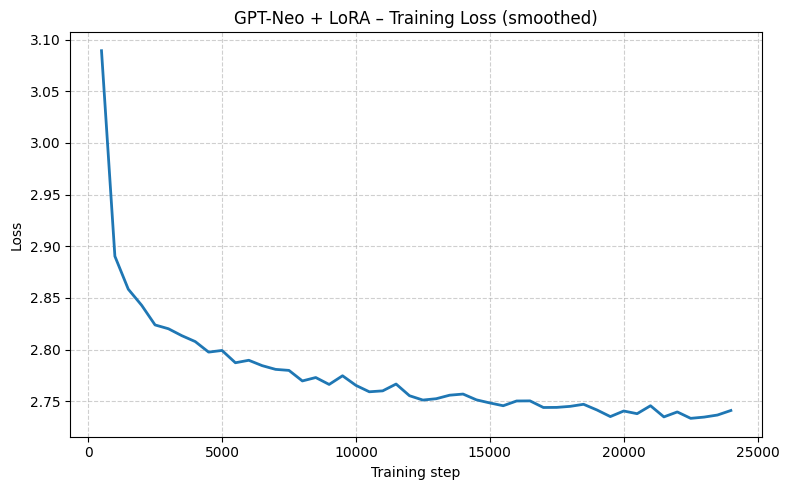

In [9]:
# === Cell 9: Training Loss Curve ===
logs = trainer.state.log_history
train_steps, train_losses = [], []
for log in logs:
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
train_steps  = np.array(train_steps)
train_losses = np.array(train_losses)

window = 50
if len(train_losses) >= window:
    kernel = np.ones(window)/window
    train_losses_smooth = np.convolve(train_losses, kernel, mode="valid")
    train_steps_smooth  = train_steps[window-1:]
else:
    train_losses_smooth = train_losses
    train_steps_smooth  = train_steps

plt.figure(figsize=(8,5))
plt.plot(train_steps_smooth, train_losses_smooth, linewidth=2)
plt.title("GPT-Neo + LoRA – Training Loss (smoothed)")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
def generate_completion(
    model,
    tokenizer,
    prompt: str,
    decoding: str = "greedy",
    temperature: float = 1.0,
    top_p: float = 0.9,
    max_new_tokens: int = MAX_NEW_TOKENS,
    stop_at_first_sentence: bool = True,
    max_tokens_first_sentence: int = 30,  # new: hard token limit for first sentence
):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(DEVICE)
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    if decoding == "greedy":
        outputs = model.generate(**inputs, do_sample=False, **gen_kwargs)
    elif decoding == "temperature":
        outputs = model.generate(**inputs, do_sample=True, temperature=temperature, **gen_kwargs)
    elif decoding == "top_p":
        outputs = model.generate(**inputs, do_sample=True, top_p=top_p, temperature=temperature, **gen_kwargs)
    else:
        raise ValueError("decoding must be one of 'greedy', 'temperature', 'top_p'")

    generated = tokenizer.decode(outputs[0, inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

    # First sentence truncation
    if stop_at_first_sentence:
        first_sent = first_sentence_only(generated)
        # Enforce hard max token limit
        tokenized_sent = tokenizer(first_sent, truncation=True, max_length=max_tokens_first_sentence)
        generated = tokenizer.decode(tokenized_sent["input_ids"], skip_special_tokens=True)

    return generated.strip()


In [11]:
# === Cell 9: Batched generation helper ===

def batched_generate(
    model,
    tokenizer,
    prompts: List[str],
    decoding: str = "greedy",
    max_new_tokens: int = 40,
    batch_size: int = 16,
    stop_at_first_sentence: bool = True,
    temperature: float = 1.0,
    top_p: float = 0.9,
):
    model.eval()
    out = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i : i + batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
        gen_kwargs = dict(max_new_tokens=max_new_tokens, pad_token_id=tokenizer.eos_token_id, eos_token_id=tokenizer.eos_token_id)
        if decoding == "greedy":
            outputs = model.generate(**enc, do_sample=False, **gen_kwargs)
        elif decoding == "temperature":
            outputs = model.generate(**enc, do_sample=True, temperature=temperature, **gen_kwargs)
        elif decoding == "top_p":
            outputs = model.generate(**enc, do_sample=True, top_p=top_p, temperature=temperature, **gen_kwargs)
        else:
            raise ValueError("decoding must be one of 'greedy', 'temperature', 'top_p'")

        for k in range(outputs.size(0)):
            gen_tokens = outputs[k, enc["input_ids"].shape[1] :]
            text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
            if stop_at_first_sentence:
                text = first_sentence_only(text)
            out.append(text.strip())
    return out

In [12]:
# === Cell 10: Metrics setup (BLEU, ROUGE, BERTScore) ===
from evaluate import load
from rouge_score import rouge_scorer

bleu_metric = load("sacrebleu")
rouge_metric = load("rouge")
bertscore_metric = load("bertscore")

# --- Helper: ROUGE-L recall macro ---

def rougeL_recall_macro(preds: List[str], refs: List[str]) -> float:
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    recalls = []
    for p, r in zip(preds, refs):
        score = scorer.score(r, p)["rougeL"]
        recalls.append(score.recall)
    return float(np.mean(recalls)) if recalls else 0.0

# --- Helper: BERTScore-F1 mean (chunks) ---

def bertscore_f1_mean(preds: List[str], refs: List[str], chunk: int = 2000) -> float:
    f1_all = []
    for i in range(0, len(preds), chunk):
        bpred = preds[i : i + chunk]
        bref = refs[i : i + chunk]
        bs = bertscore_metric.compute(predictions=bpred, references=bref, lang="en")
        f1_all.extend(bs["f1"])
    return float(np.mean(f1_all)) if f1_all else 0.0

In [13]:
# === Cell 11: Semantic coherence (embedding cosine similarity) ===

# Use a compact sentence-transformer model to compute similarity
embedder = SentenceTransformer("all-MiniLM-L6-v2")


def semantic_coherence_score(preds: List[str], refs: List[str]) -> float:
    """Compute mean cosine similarity between predicted continuations and references.
    Returns a value in [0,1]."""
    if not preds:
        return 0.0
    emb_preds = embedder.encode(preds, convert_to_numpy=True, show_progress_bar=False)
    emb_refs = embedder.encode(refs, convert_to_numpy=True, show_progress_bar=False)
    # cosine similarity row-wise
    norms_p = np.linalg.norm(emb_preds, axis=1)
    norms_r = np.linalg.norm(emb_refs, axis=1)
    dot = np.sum(emb_preds * emb_refs, axis=1)
    cos = dot / (norms_p * norms_r + 1e-12)
    # map from [-1,1] to [0,1]
    cos01 = (cos + 1.0) / 2.0
    return float(np.mean(cos01))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
# === Cell 12: Perplexity for generated continuations ===

def continuation_perplexity_generated(model, tokenizer, prompts, preds, device, max_length=128, batch_size=16):
    model.eval()
    losses = []
    for i in range(0, len(prompts), batch_size):
        bp = prompts[i : i + batch_size]
        br = preds[i : i + batch_size]
        full_texts = [p + " " + tokenizer.eos_token + " " + r for p, r in zip(bp, br)]
        enc = tokenizer(full_texts, return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(device)
        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100
        # mask prompt tokens so loss only computed on generated continuation
        prompt_lens = [tokenizer(p + " " + tokenizer.eos_token, return_tensors="pt").input_ids.shape[1] for p in bp]
        for row, pl in enumerate(prompt_lens):
            labels[row, :pl] = -100
        with torch.no_grad():
            loss = model(**enc, labels=labels).loss
            losses.append(loss.item())
    return float(np.exp(np.mean(losses))) if losses else float("inf")

In [15]:
# === Cell 13: Evaluation on FULL test set ===

def evaluate_strategy_full(model, tokenizer, prompts, refs, decoding_type: str):
    """
    Evaluates using ALL test samples provided in `prompts` and `refs`.
    """
    # Use the full dataset
    preds = batched_generate(
        model,
        tokenizer,
        prompts,
        decoding=decoding_type,
        max_new_tokens=MAX_NEW_TOKENS,
        batch_size=16
    )

    # Avoid crashes from empty predictions
    safe_preds_for_overlap = [p if p.strip() else " " for p in preds]

    # BLEU
    bleu = bleu_metric.compute(
        predictions=safe_preds_for_overlap,
        references=[[r] for r in refs]
    )["score"]

    # ROUGE-L (F1 + Recall)
    rouge_f1 = rouge_metric.compute(
        predictions=safe_preds_for_overlap,
        references=refs,
        use_stemmer=True,
        use_aggregator=True,
        rouge_types=["rougeL"]
    )
    rougeL_f1 = float(rouge_f1["rougeL"])
    rougeL_recall = rougeL_recall_macro(safe_preds_for_overlap, refs)

    # For metrics that need non-empty predictions
    non_empty_preds = [p for p in preds if p.strip()]
    non_empty_refs = [r for p, r in zip(preds, refs) if p.strip()]

    if non_empty_preds:
        bs_f1 = bertscore_f1_mean(non_empty_preds, non_empty_refs)
        coherence = semantic_coherence_score(non_empty_preds, non_empty_refs)
    else:
        bs_f1 = 0.0
        coherence = 0.0

    # Perplexity on generated continuations
    ppl_generated = continuation_perplexity_generated(
        model,
        tokenizer,
        prompts,
        preds,
        DEVICE,
        max_length=MAX_LENGTH,
        batch_size=16
    )

    return {
        "BLEU": bleu,
        "ROUGE_F1": rougeL_f1,
        "ROUGE_Recall": rougeL_recall,
        "BERTScore-F1": bs_f1,
        "SemanticCoherence": coherence,
        "Perplexity": ppl_generated,
    }


In [16]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="A decoder-only architecture is being used, but right-padding was detected!"
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

=== Decoding Evaluation Results (FULL test set: 19410 samples) ===


,BLEU,ROUGE_F1,ROUGE_Recall,BERTScore-F1,SemanticCoherence,Perplexity
greedy,1.806458,0.171229,0.164640,0.887208,0.705218,95.639778
temperature,0.647207,0.128678,0.131258,0.876915,0.677312,131.181273
top_p,0.762582,0.138967,0.140303,0.879391,0.683499,119.532106



=== GOLD Continuation Perplexity (FULL test set: 19410 samples) ===
15.8603


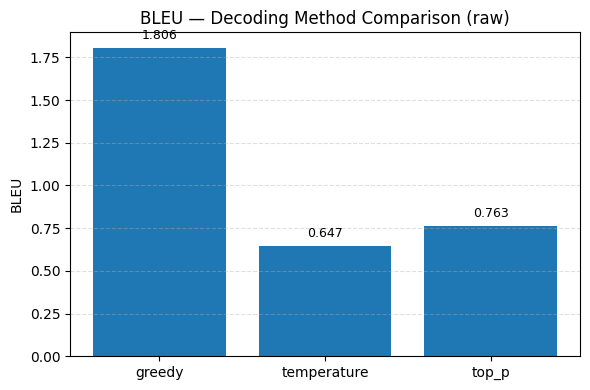

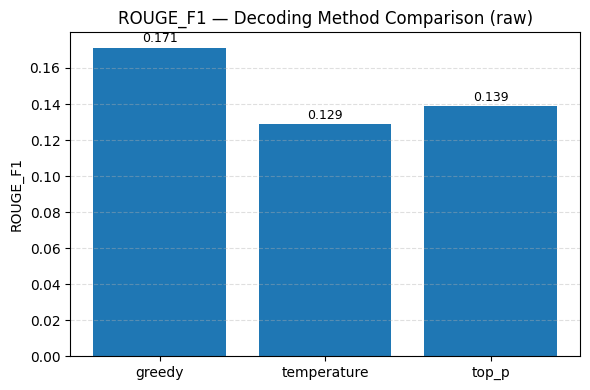

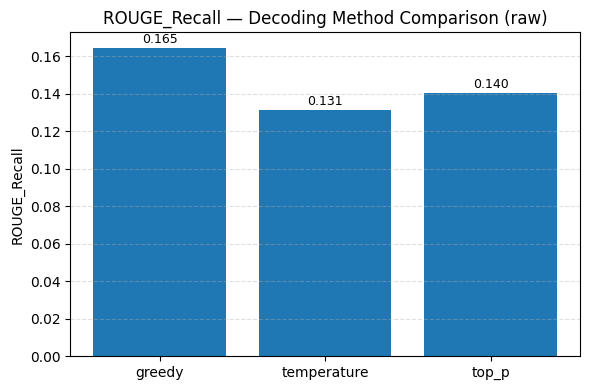

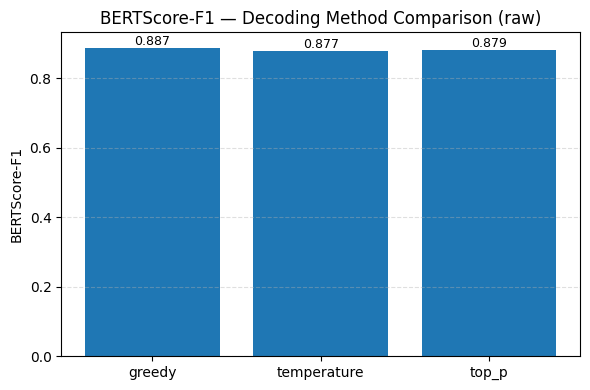

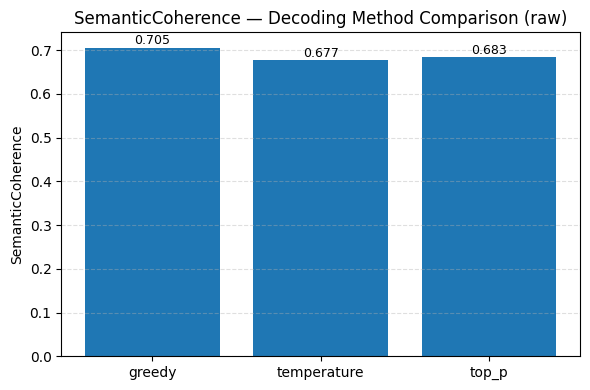

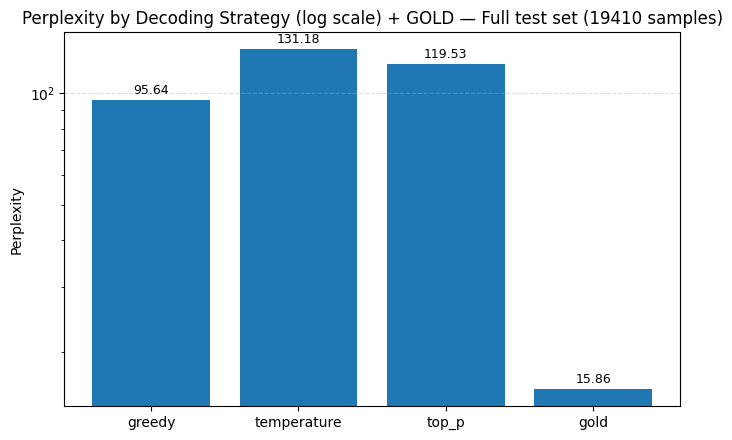

In [18]:
import math
import numpy as np
import torch
from torch.nn import CrossEntropyLoss
import matplotlib.pyplot as plt
import pandas as pd
from transformers import logging

# --- Fix NLTK punkt_tab error ---
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# --- Suppress transformers warnings ---
logging.set_verbosity_error()

# --- Ensure tokenizer is correctly set for decoder-only model ---
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# --- Prepare full test prompts/targets ---
_prompts = [ex["prompt"] for ex in ds["test"]]
_targets = [ex["target"] for ex in ds["test"]]

# -----------------------------------------------------------
# 1) Evaluate Greedy / Temperature / Top-P (FULL test set)
# -----------------------------------------------------------
results = {
    dec: evaluate_strategy_full(model, tokenizer, _prompts, _targets, dec)
    for dec in ["greedy", "temperature", "top_p"]
}

df_results = pd.DataFrame(results).T.round(6)
print(f"=== Decoding Evaluation Results (FULL test set: {len(_prompts)} samples) ===")
display(df_results)

# -----------------------------------------------------------
# 2) Compute GOLD continuation perplexity (FULL test set)
# -----------------------------------------------------------
def gold_continuation_perplexity(model, tokenizer, prompts, targets, max_length=128):
    model.eval()
    losses = []
    loss_fn = CrossEntropyLoss()

    for prompt, target in zip(prompts, targets):
        full_text = prompt + " " + target
        enc = tokenizer(
            full_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length
        )
        ids = enc["input_ids"].to(model.device)

        # boundary where target begins
        prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
        target_start = len(prompt_ids)

        with torch.no_grad():
            logits = model(ids).logits[:, :-1, :]
            labels = ids[:, 1:].clone()
            labels[:, :target_start] = -100  # mask prompt tokens

            loss = loss_fn(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1)
            )
            losses.append(loss.item())

    return float(np.exp(np.mean(losses))) if losses else float("nan")

gold_ppl = gold_continuation_perplexity(model, tokenizer, _prompts, _targets)
print(f"\n=== GOLD Continuation Perplexity (FULL test set: {len(_prompts)} samples) ===\n{gold_ppl:.4f}")

# -----------------------------------------------------------
# 3) Plot metrics (raw values)
# -----------------------------------------------------------
all_metrics = list(df_results.columns)
core_metrics = [m for m in all_metrics if "perplex" not in m.lower() and "ppl" not in m.lower()]

if not core_metrics:
    print("No core metrics found (only perplexity).")
else:
    for metric in core_metrics:
        plt.figure(figsize=(6, 4))
        vals = df_results[metric].astype(float)
        bars = plt.bar(vals.index, vals.values)

        for bar, v in zip(bars, vals.values):
            offset = (max(vals) - min(vals)) * 0.03 if max(vals) != min(vals) else 0.02
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                v + offset,
                f"{v:.3f}",
                ha="center", va="bottom", fontsize=9
            )

        plt.ylabel(metric)
        plt.title(f"{metric} — Decoding Method Comparison (raw)")
        plt.grid(axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()

# -----------------------------------------------------------
# 4) Perplexity plot (separate + GOLD)
# -----------------------------------------------------------
perp_vals = {}

# detect perplexity column if present
ppl_cols = [c for c in df_results.columns if "perplex" in c.lower() or "ppl" in c.lower()]
if ppl_cols:
    ppl_col = ppl_cols[0]
    for dec in df_results.index:
        val = df_results.loc[dec, ppl_col]
        perp_vals[dec] = float(val) if not pd.isna(val) else np.nan
else:
    for dec in ["greedy", "temperature", "top_p"]:
        perp_vals[dec] = np.nan

labels = list(perp_vals.keys()) + ["gold"]
values = list(perp_vals.values()) + [gold_ppl]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(labels, values)
plt.yscale("log")
plt.title(f"Perplexity by Decoding Strategy (log scale) + GOLD — Full test set ({len(_prompts)} samples)")
plt.ylabel("Perplexity")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, val in zip(bars, values):
    if np.isnan(val):
        ann = "NaN"
        ypos = 1.0
    else:
        ann = f"{val:.2f}"
        ypos = val * 1.02
    plt.text(bar.get_x() + bar.get_width() / 2, ypos, ann, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [19]:
# === Cell 15: Export samples for human eval ===

def export_samples_for_human_eval(model, tokenizer, N_SAMPLES=30, output_dir=OUTPUT_DIR):
    human_subset = ds["test"].select(range(min(N_SAMPLES, len(ds["test"]))))
    rows = []
    for ex in human_subset:
        prompt = ex["prompt"]
        gold = ex["target"]
        greedy = generate_completion(model, tokenizer, prompt, decoding="greedy")
        temp = generate_completion(model, tokenizer, prompt, decoding="temperature")
        top_p_pred = generate_completion(model, tokenizer, prompt, decoding="top_p")
        rows.append({"prompt": prompt, "gold_ending": gold, "greedy_ending": greedy, "temperature_ending": temp, "top_p_ending": top_p_pred})
    df_human = pd.DataFrame(rows)
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, "gptneo_story_samples_for_human_eval.csv")
    df_human.to_csv(csv_path, index=False)
    return csv_path

# -- end of file --
# Notes:
# - Lines that run heavy compute (trainer.train(), evaluate, embedding encoding) are commented out
#   so you can selectively run them in your environment after loading/saving models.
# - The script includes a simple semantic coherence implementation using SentenceTransformers.
# - If you want me to also provide a ready-to-run Colab notebook (.ipynb) or to uncomment and
#   run training/evaluation here, tell me which parts you want enabled and the compute budget.
